# Habituation / repeated-exposure analysis

This notebook generates the final analysis tables and draft figures for the habituation phase of the AIR Wheel behavioral experiment.

The goal is to quantify whether repeated head-fixed wheel exposure changes:

1. **whole-session locomotor state** across habituation sessions,
2. **within-session locomotor dynamics** across time in each session, and
3. whether the results are robust to animal-level variability.

Primary outcomes are restricted to the three measures reported in the manuscript:

- fraction moving,
- fraction forward,
- speed, defined as path speed in cm/s.

## 1. Analysis settings

These constants define the primary outcomes, labels, habituation phase name, movement threshold, and the common within-session analysis window.

In [1]:
PRIMARY_OUTCOMES = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

OUTCOME_LABELS = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

HAB_PHASE = "habituation"
SPEED_THRESH = 0.5
MAX_SESSION_TIME_MIN = 20.0

## 2. Load project context and cached behavioral epoch data

This section loads the project paths, epoch-window tables, behavioral epoch metrics, QC tables, and session-day metadata. The session-day table is used to identify good sessions and assign phase/session numbers.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


### Inspect session-day metadata

This quick display is mainly a sanity check to confirm that session availability and phase/session numbering were loaded correctly.

In [3]:
session_day_df

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total,date_dt,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
0,NML_04,2025_12_27,habituation,1310.8,42,42,False,True,True,42,...,0,0,0,0,503,2025-12-27,1.0,16.0,0.000000,early
1,NML_04,2025_12_28,habituation,1473.4,43,43,False,True,True,43,...,0,0,0,0,516,2025-12-28,2.0,16.0,0.066667,early
2,NML_04,2025_12_29,habituation,1254.5,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-29,3.0,16.0,0.133333,early
3,NML_04,2025_12_30,habituation,1624.2,53,53,False,True,True,53,...,0,0,0,0,636,2025-12-30,4.0,16.0,0.200000,early
4,NML_04,2025_12_31,habituation,1326.6,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-31,5.0,16.0,0.266667,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-17,6.0,10.0,0.555556,middle
209,NML_08,2026_03_18,tone_air_training,1236.0,51,51,False,True,True,0,...,51,51,51,51,612,2026-03-18,7.0,10.0,0.666667,middle
210,NML_08,2026_03_19,tone_air_training,1214.1,50,50,False,True,True,0,...,50,50,50,50,600,2026-03-19,8.0,10.0,0.777778,late
211,NML_08,2026_03_20,tone_air_training,1220.1,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-20,9.0,10.0,0.888889,late


## 3. Define output folder for figures and tables

All draft figures and model-output tables are saved into the processed-data figure directory.

In [4]:
from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

PosixPath('/mnt/pdata/Classical_Conditioning/figures')

## 4. Whole-session habituation dataframe

Here we compute one row per animal-session using whole-session locomotor metrics. This dataframe is used for the first Results section: repeated exposure effects across habituation sessions.

In [ ]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_summary_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_df.head()

### Save and reload the whole-session dataframe

The whole-session metrics are saved to HDF5 so that the analysis can be reproduced without recomputing them every time.

In [ ]:
from pathlib import Path
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

pdio.save_df_h5(
    df=hab_df,
    h5_path=out_file,
    key="whole_session/habituation_speedThresh_0p5",
    overwrite=True,
    metadata={
        "phase": "habituation",
        "speed_thresh": 0.5,
        "good_sessions_only": True,
        "description": "Whole-session locomotor metrics for habituation phase",
    },
)

In [6]:
out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

hab_df_loaded = pd.read_hdf(
    out_file,
    key="whole_session/habituation_speedThresh_0p5"
)

hab_df_loaded.head()

hab_df = hab_df_loaded.copy()

## 5. Prepare whole-session dataframe for LME

This section adds a unique animal-day/session identifier and creates `exposure_session_c`.

`exposure_session_c` is the exposure session number centered at the mean session number. The slope is still interpreted as change per additional exposure session.

In [7]:
hab_session_df = hab_df.copy()

# Animal-day/session ID
hab_session_df["animal_day"] = (
    hab_session_df["animal"].astype(str) + ":" +
    hab_session_df["date"].astype(str)
)

# Exposure session number
if "exposure_session" not in hab_session_df.columns:
    if "phase_session_number" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_session_number"]
    elif "phase_day_number_good" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day_number_good"]
    elif "phase_day" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day"]
    else:
        raise ValueError("Could not find exposure/session/day column.")

hab_session_df["exposure_session"] = hab_session_df["exposure_session"].astype(float)

hab_session_df["exposure_session_c"] = (
    hab_session_df["exposure_session"] -
    hab_session_df["exposure_session"].mean()
)

print(hab_session_df.shape)
print(hab_session_df.columns.tolist())
display(hab_session_df.head())

(86, 55)
['animal', 'date', 'phase', 'fs', 'n_samples', 'recording_duration_s', 'short_recording', 'n_onsets', 'n_offsets', 'n_pairs', 'n_invalid_pair', 'n_edge_excluded', 'n_short_led', 'n_tone_structure_bad', 'n_short_recording_excluded', 'n_valid_for_epoch_extraction', 'status', 'date_dt', 'rig_day_from_date', 'rig_session_number', 'phase_day_from_date', 'phase_session_number', 'recording_duration_min', 'rig_session_start_s', 'rig_session_start_min', 'phase_session_start_s', 'phase_session_start_min', 'rig_calendar_day', 'phase_calendar_day', 'speed_thresh_cms', 'n_samples_used', 'duration_s_used', 'duration_min_used', 'total_distance_path_cm', 'total_distance_net_cm', 'distance_path_per_min', 'distance_net_per_min', 'net_direction_bias', 'mean_speed_path_cms', 'median_speed_path_cms', 'peak_speed_path_cms', 'mean_speed_net_cms', 'median_speed_net_cms', 'min_speed_net_cms', 'max_speed_net_cms', 'frac_stationary', 'frac_moving', 'frac_forward', 'frac_backward', 'frac_low_net_movement

,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session,animal_day,exposure_session,exposure_session_c
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok,NML_04:2025_12_27,1.0,-8.162791
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok,NML_04:2025_12_28,2.0,-7.162791
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok,NML_04:2025_12_29,3.0,-6.162791
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok,NML_04:2025_12_30,4.0,-5.162791
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok,NML_04:2025_12_31,5.0,-4.162791


## 6. Enable R in the notebook

The mixed-effects models are fit in R using `lme4`/`lmerTest`, while Python is used for data organization and saving tables.

In [8]:
%load_ext rpy2.ipython

## 7. Whole-session LME models

For each primary outcome, we fit:

`outcome ~ exposure_session_c + (1 | animal)`

This model asks whether the outcome changes across habituation sessions while allowing each animal to have its own baseline level.

In [9]:
%%R -i hab_session_df -o hab_session_results_R

library(lme4)
library(lmerTest)
library(broom.mixed)
library(dplyr)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

print(primary_outcomes)

# --------------------------------------------------
# Whole-session models
# outcome ~ exposure_session_c + (1 | animal)
# --------------------------------------------------

session_results <- list()
session_models <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting:", outcome, "\n")
  cat("==============================\n")

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c + (1 | animal)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_session_df,
    REML = FALSE
  )

  session_models[[outcome]] <- m

  tmp <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )

  tmp$outcome <- outcome
  session_results[[outcome]] <- tmp

  print(summary(m))
}

hab_session_results_R <- bind_rows(session_results) %>%
  relocate(outcome)

print(hab_session_results_R)

R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "frac_moving"         "frac_forward"        "mean_speed_path_cms"


Fitting: frac_moving 
Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: as.formula(formula_text)
   Data: hab_session_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    -78.7     -68.9      43.3     -86.7        82 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.15800 -0.63575 -0.06073  0.52139  2.07859 

Random effects:
 Groups   Name        Variance Std.Dev.
 animal   (Intercept) 0.02893  0.1701  
 Residual             0.01756  0.1325  
Number of obs: 86, groups:  animal, 5

Fixed effects:
                    Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)         0.308588   0.077405  5.023377   3.987   0.0104 *  
exposure_session_c  0.019879   0.002851 81.141128   6.974 7.53e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
expsr_sssn

### Format whole-session model results for manuscript reporting

This converts the R fixed-effect output into compact manuscript-style statistical text.

In [10]:
import pandas as pd
import numpy as np

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

def make_lme_report_table(df):
    report_df = df.copy()

    report_df["report_text"] = report_df.apply(
        lambda r: (
            f"β = {r['estimate']:.4f}, "
            f"SE = {r['std.error']:.4f}, "
            f"t({r['df']:.1f}) = {r['statistic']:.2f}, "
            f"{format_p(r['p.value'])}"
        ),
        axis=1
    )

    return report_df[
        ["outcome", "term", "estimate", "std.error", "statistic", "df", "p.value", "report_text"]
    ]

hab_session_report = make_lme_report_table(hab_session_results_R)

display(
    hab_session_report[
        hab_session_report["term"] != "(Intercept)"
    ]
)

,outcome,term,estimate,std.error,statistic,df,p.value,report_text
2,frac_moving,exposure_session_c,0.019879,0.002851,6.973667,81.141128,7.527844e-10,"β = 0.0199, SE = 0.0029, t(81.1) = 6.97, p < 0..."
4,frac_forward,exposure_session_c,0.022092,0.002938,7.520214,81.148312,6.512035e-11,"β = 0.0221, SE = 0.0029, t(81.1) = 7.52, p < 0..."
6,mean_speed_path_cms,exposure_session_c,0.263730,0.042159,6.255597,81.233242,1.751517e-08,"β = 0.2637, SE = 0.0422, t(81.2) = 6.26, p < 0..."


## 8. Figure 1A–C: whole-session repeated-exposure effects

This figure shows the raw animal-session values, individual animal trajectories, and the fixed-effect LME prediction for each primary outcome.

The figure is saved as PDF/PNG in the figure directory.

R[write to console]: RStudio Community is a great place to get help:
https://community.rstudio.com/c/tidyverse

Fontconfig warning: using without calling FcInit()


              outcome          y_label       beta          se       df        t
1         frac_moving  Fraction moving 0.01987890 0.002850566 81.14113 6.973667
2        frac_forward Fraction forward 0.02209222 0.002937712 81.14831 7.520214
3 mean_speed_path_cms     Speed (cm/s) 0.26372985 0.042159020 81.23324 6.255597
             p                      stat_label
1 7.527844e-10 beta = 0.020/session\np < 0.001
2 6.512035e-11 beta = 0.022/session\np < 0.001
3 1.751517e-08 beta = 0.264/session\np < 0.001


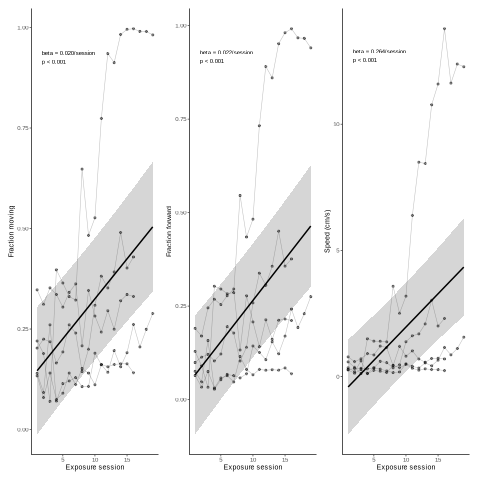

In [11]:
%%R -i hab_session_df -i fig_dir_str

library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)
library(patchwork)

# --------------------------------------------------
# Output folder
# --------------------------------------------------

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Helper: p-value formatting
# --------------------------------------------------

format_p <- function(p) {
  if (is.na(p)) {
    return("p = NA")
  } else if (p < 0.001) {
    return("p < 0.001")
  } else {
    return(paste0("p = ", sprintf("%.3f", p)))
  }
}

# --------------------------------------------------
# Helper: fixed-effect prediction with 95% CI
# --------------------------------------------------

predict_fixed_ci <- function(model, newdata) {
  fixed_formula <- formula(model, fixed.only = TRUE)
  X <- model.matrix(delete.response(terms(fixed_formula)), newdata)
  beta <- fixef(model)
  V <- vcov(model)

  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% V %*% t(X)))

  newdata$fit <- fit
  newdata$se <- se
  newdata$lower <- fit - 1.96 * se
  newdata$upper <- fit + 1.96 * se

  return(newdata)
}

# --------------------------------------------------
# Theme
# --------------------------------------------------

theme_fig <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text = element_text(size = 6),
      plot.title = element_blank(),
      plot.subtitle = element_blank(),
      legend.position = "none",
      plot.margin = margin(3, 5, 3, 3)
    )
}

# --------------------------------------------------
# Fit models and make one plot per outcome
# --------------------------------------------------

plot_list <- list()
stats_list <- list()

for (outcome in primary_outcomes) {

  label_i <- unname(outcome_labels[outcome])

  m <- lmer(
    as.formula(paste0(outcome, " ~ exposure_session_c + (1 | animal)")),
    data = hab_session_df,
    REML = FALSE
  )

  sm <- summary(m)
  coef_table <- as.data.frame(sm$coefficients)

  beta <- coef_table["exposure_session_c", "Estimate"]
  se <- coef_table["exposure_session_c", "Std. Error"]
  df <- coef_table["exposure_session_c", "df"]
  tval <- coef_table["exposure_session_c", "t value"]
  pval <- coef_table["exposure_session_c", "Pr(>|t|)"]

  # Use plain "beta" to avoid Greek font/rendering problems
  stat_label <- paste0(
    "beta = ", sprintf("%.3f", beta), "/session\n",
    format_p(pval)
  )

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    y_label = label_i,
    beta = beta,
    se = se,
    df = df,
    t = tval,
    p = pval,
    stat_label = stat_label
  )

  exposure_seq <- seq(
    min(hab_session_df$exposure_session, na.rm = TRUE),
    max(hab_session_df$exposure_session, na.rm = TRUE),
    length.out = 100
  )

  exposure_mean <- mean(hab_session_df$exposure_session, na.rm = TRUE)

  pred_df <- data.frame(
    exposure_session = exposure_seq,
    exposure_session_c = exposure_seq - exposure_mean
  )

  pred_df <- predict_fixed_ci(m, pred_df)

  raw_df <- hab_session_df %>%
    select(animal, exposure_session, all_of(outcome)) %>%
    rename(y = all_of(outcome))

  x_annot <- min(raw_df$exposure_session, na.rm = TRUE) +
    0.04 * diff(range(raw_df$exposure_session, na.rm = TRUE))

  y_annot <- max(raw_df$y, na.rm = TRUE) -
    0.06 * diff(range(raw_df$y, na.rm = TRUE))

  p <- ggplot() +
    geom_line(
      data = raw_df,
      aes(x = exposure_session, y = y, group = animal),
      alpha = 0.25,
      linewidth = 0.25
    ) +
    geom_point(
      data = raw_df,
      aes(x = exposure_session, y = y),
      alpha = 0.45,
      size = 0.8
    ) +
    geom_ribbon(
      data = pred_df,
      aes(x = exposure_session, ymin = lower, ymax = upper),
      alpha = 0.20
    ) +
    geom_line(
      data = pred_df,
      aes(x = exposure_session, y = fit),
      linewidth = 0.7
    ) +
    annotate(
      "text",
      x = x_annot,
      y = y_annot,
      label = stat_label,
      hjust = 0,
      vjust = 1,
      size = 2.1
    ) +
    labs(
      x = "Exposure session",
      y = label_i
    ) +
    theme_fig()

  plot_list[[outcome]] <- p
}

# --------------------------------------------------
# Combine panels
# --------------------------------------------------

p_combined <- plot_list[[primary_outcomes[1]]] +
  plot_list[[primary_outcomes[2]]] +
  plot_list[[primary_outcomes[3]]] +
  plot_layout(nrow = 1)

print(p_combined)

# --------------------------------------------------
# Save
# --------------------------------------------------

ggsave(
  filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.pdf"),
  plot = p_combined,
  width = 7,
  height = 1.9
)

ggsave(
  filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.png"),
  plot = p_combined,
  width = 7,
  height = 1.9,
  dpi = 600
)

# SVG should work after installing r-svglite
ggsave(
  filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.svg"),
  plot = p_combined,
  width = 7,
  height = 1.9
)

# --------------------------------------------------
# Save stats table
# --------------------------------------------------

hab_whole_session_stats_df <- bind_rows(stats_list)

write.csv(
  hab_whole_session_stats_df,
  file.path(out_dir, "habituation_whole_session_LME_stats.csv"),
  row.names = FALSE
)

print(hab_whole_session_stats_df)

## 9. Animal-level sensitivity analysis

The whole-session figure shows that one animal has a particularly large increase, especially for speed. To check whether the repeated-exposure effect is driven only by this high-responder, we estimate a separate slope for each animal and summarize how many animals show a positive slope.

In [12]:
%%R -i hab_session_df -o animal_slope_results_df -o animal_slope_summary_df

library(dplyr)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

animal_slope_results <- list()

for (outcome in primary_outcomes) {

  tmp <- hab_session_df %>%
    group_by(animal) %>%
    group_modify(~{
      fit <- lm(as.formula(paste0(outcome, " ~ exposure_session")), data = .x)
      coefs <- summary(fit)$coefficients

      data.frame(
        n_sessions = nrow(.x),
        df = df.residual(fit),
        beta = coefs["exposure_session", "Estimate"],
        se = coefs["exposure_session", "Std. Error"],
        t = coefs["exposure_session", "t value"],
        p = coefs["exposure_session", "Pr(>|t|)"]
      )
    }) %>%
    ungroup() %>%
    mutate(outcome = outcome)

  animal_slope_results[[outcome]] <- tmp
}

animal_slope_results_df <- bind_rows(animal_slope_results)

animal_slope_summary_df <- animal_slope_results_df %>%
  group_by(outcome) %>%
  summarise(
    n_animals = n(),
    n_positive = sum(beta > 0),
    mean_beta = mean(beta, na.rm = TRUE),
    median_beta = median(beta, na.rm = TRUE),
    min_beta = min(beta, na.rm = TRUE),
    max_beta = max(beta, na.rm = TRUE),
    .groups = "drop"
  )

print(animal_slope_results_df)
print(animal_slope_summary_df)

# A tibble: 15 × 8
   animal n_sessions    df     beta      se      t        p outcome            
   <chr>       <int> <int>    <dbl>   <dbl>  <dbl>    <dbl> <chr>              
 1 NML_04         16    14 -0.00253 0.00240 -1.05  3.10e- 1 frac_moving        
 2 NML_05         16    14  0.0187  0.00326  5.73  5.24e- 5 frac_moving        
 3 NML_06         16    14  0.00412 0.00128  3.20  6.38e- 3 frac_moving        
 4 NML_07         19    17  0.0556  0.00480 11.6   1.70e- 9 frac_moving        
 5 NML_08         19    17  0.00738 0.00207  3.57  2.35e- 3 frac_moving        
 6 NML_04         16    14 -0.00221 0.00274 -0.808 4.33e- 1 frac_forward       
 7 NML_05         16    14  0.0228  0.00296  7.70  2.14e- 6 frac_forward       
 8 NML_06         16    14  0.00216 0.00100  2.16  4.88e- 2 frac_forward       
 9 NML_07         19    17  0.0593  0.00451 13.1   2.49e-10 frac_forward       
10 NML_08         19    17  0.0106  0.00178  5.93  1.64e- 5 frac_forward       
11 NML_04         16 

### Leave-one-animal-out sensitivity analysis

This optional sensitivity analysis refits the whole-session LME after removing one animal at a time. The goal is to determine whether the exposure-session effect remains positive when any single animal is excluded.

In [13]:
%%R -i hab_session_df

library(lme4)
library(lmerTest)
library(dplyr)

hab_session_df$animal <- factor(hab_session_df$animal)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

loo_results <- list()

for (outcome in primary_outcomes) {

  animals <- levels(hab_session_df$animal)

  for (a in animals) {

    df_sub <- hab_session_df %>%
      filter(animal != a)

    m <- lmer(
      as.formula(paste0(outcome, " ~ exposure_session_c + (1 | animal)")),
      data = df_sub,
      REML = FALSE
    )

    coef_table <- as.data.frame(summary(m)$coefficients)

    loo_results[[paste(outcome, a, sep = "_")]] <- data.frame(
      outcome = outcome,
      animal_removed = a,
      beta = coef_table["exposure_session_c", "Estimate"],
      se = coef_table["exposure_session_c", "Std. Error"],
      df = coef_table["exposure_session_c", "df"],
      t = coef_table["exposure_session_c", "t value"],
      p = coef_table["exposure_session_c", "Pr(>|t|)"]
    )
  }
}

loo_results_df <- bind_rows(loo_results)

print(loo_results_df)

               outcome animal_removed        beta          se       df        t
1          frac_moving         NML_04 0.024053330 0.003151642 66.09173 7.632001
2          frac_moving         NML_05 0.020095894 0.003377964 66.10311 5.949115
3          frac_moving         NML_06 0.022787940 0.003307717 66.13597 6.889326
4          frac_moving         NML_07 0.006948889 0.001439411 63.06828 4.827592
5          frac_moving         NML_08 0.024449197 0.003547693 63.10872 6.891577
6         frac_forward         NML_04 0.026610313 0.003210122 66.09389 8.289503
7         frac_forward         NML_05 0.021955547 0.003496016 66.10904 6.280162
8         frac_forward         NML_06 0.025778122 0.003347551 66.13725 7.700591
9         frac_forward         NML_07 0.008613373 0.001539203 63.10174 5.595997
10        frac_forward         NML_08 0.026310290 0.003708730 63.11232 7.094151
11 mean_speed_path_cms         NML_04 0.313848541 0.048373757 66.16863 6.487992
12 mean_speed_path_cms         NML_05 0.

## 10. Build epoch-level habituation dataframe

The within-session analysis requires an epoch-level dataframe, not the whole-session dataframe. Here we extract habituation epochs from `encoder_epoch_df`, add animal-day IDs, add exposure-session numbers, add within-session time, and keep only the primary outcomes.

`session_time_10m_c` is within-session time centered at the mean sampled time and scaled by 10 minutes. Its coefficient is interpreted as change per 10 minutes later within a session.

In [21]:
import numpy as np
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Build habituation epoch-level dataframe
# --------------------------------------------------

df0 = encoder_epoch_df.copy()

print("Available phases:")
print(df0["phase"].value_counts())

# Detect habituation phase
phase_vals = df0["phase"].dropna().astype(str).unique().tolist()

if "habituation" in phase_vals:
    hab_phase = "habituation"
else:
    hab_candidates = [
        p for p in phase_vals
        if ("hab" in p.lower()) or ("exposure" in p.lower())
    ]
    if len(hab_candidates) == 0:
        raise ValueError(f"Could not identify habituation phase. Available phases: {phase_vals}")
    hab_phase = hab_candidates[0]

print("Using habituation phase:", hab_phase)

hab_epoch_df = df0[df0["phase"].astype(str) == hab_phase].copy()

# --------------------------------------------------
# Apply validity filters if columns exist
# --------------------------------------------------

if "valid_window" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["valid_window"] == True].copy()

if "good_session_basic" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["good_session_basic"] == True].copy()

# --------------------------------------------------
# Animal-day/session ID
# --------------------------------------------------

if "date" in hab_epoch_df.columns:
    hab_epoch_df["animal_day"] = (
        hab_epoch_df["animal"].astype(str) + ":" +
        hab_epoch_df["date"].astype(str)
    )
else:
    raise ValueError("date column not found; need a session/date identifier.")

# --------------------------------------------------
# Add exposure session number
# --------------------------------------------------

if "exposure_session" not in hab_epoch_df.columns:
    if "phase_session_number" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_session_number"]
    elif "phase_day_number_good" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day_number_good"]
    elif "phase_day" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day"]
    else:
        # Try merging from session_day_df if available
        if "session_day_df" in globals():
            merge_cols = ["animal", "date"]
            possible_session_cols = [
                "phase_session_number",
                "phase_day_number_good",
                "phase_day",
                "training_day",
            ]
            available_session_cols = [
                c for c in possible_session_cols if c in session_day_df.columns
            ]

            if len(available_session_cols) == 0:
                raise ValueError(
                    "No session/day column found in hab_epoch_df or session_day_df."
                )

            session_col = available_session_cols[0]

            hab_epoch_df = hab_epoch_df.merge(
                session_day_df[merge_cols + [session_col]].drop_duplicates(),
                on=merge_cols,
                how="left"
            )

            hab_epoch_df["exposure_session"] = hab_epoch_df[session_col]
        else:
            raise ValueError(
                "Could not find exposure/session/day column and session_day_df is not available."
            )

hab_epoch_df["exposure_session"] = hab_epoch_df["exposure_session"].astype(float)

# --------------------------------------------------
# Add within-session time in minutes
# --------------------------------------------------

if "session_time_min" not in hab_epoch_df.columns:
    if "anchor_session_time_min" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_session_time_min"]
    elif "window_center_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["window_center_time_s"] / 60.0
    elif "anchor_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_time_s"] / 60.0
    elif "session_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["session_time_s"] / 60.0
    else:
        print("Time-related columns:")
        print([c for c in hab_epoch_df.columns if "time" in c.lower()])
        raise ValueError("Could not find a within-session time column.")

# --------------------------------------------------
# Make centered predictors
# --------------------------------------------------

hab_epoch_df["exposure_session_c"] = (
    hab_epoch_df["exposure_session"] -
    hab_epoch_df["exposure_session"].mean()
)

hab_epoch_df["session_time_10m_c"] = (
    hab_epoch_df["session_time_min"] -
    hab_epoch_df["session_time_min"].mean()
) / 10.0

# --------------------------------------------------
# Make sure primary outcomes exist
# --------------------------------------------------

if "frac_moving" not in hab_epoch_df.columns:
    if "frac_stationary" in hab_epoch_df.columns:
        hab_epoch_df["frac_moving"] = 1 - hab_epoch_df["frac_stationary"]
    elif "stationary_frac" in hab_epoch_df.columns:
        hab_epoch_df["frac_moving"] = 1 - hab_epoch_df["stationary_frac"]

primary_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

missing = [c for c in primary_outcomes if c not in hab_epoch_df.columns]
if len(missing) > 0:
    print("Missing primary outcomes:", missing)
    print("Available fraction columns:")
    print([c for c in hab_epoch_df.columns if "frac" in c.lower()])
    print("Available speed columns:")
    print([c for c in hab_epoch_df.columns if "speed" in c.lower()])
    raise ValueError("Some primary outcome columns are missing.")

# --------------------------------------------------
# Drop rows missing required values
# --------------------------------------------------

required_cols = [
    "animal",
    "animal_day",
    "exposure_session",
    "exposure_session_c",
    "session_time_min",
    "session_time_10m_c",
] + primary_outcomes

hab_epoch_df = hab_epoch_df.dropna(subset=required_cols).copy()

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("hab_epoch_df shape:", hab_epoch_df.shape)
print("n animals:", hab_epoch_df["animal"].nunique())
print("n animal-day sessions:", hab_epoch_df["animal_day"].nunique())
print("n sampled epoch windows:", len(hab_epoch_df))

print("\nExposure session summary:")
display(hab_epoch_df["exposure_session"].describe())

print("\nSession time summary:")
display(hab_epoch_df["session_time_min"].describe())

print("\nMean session time subtracted:")
print(hab_epoch_df["session_time_min"].mean())

print("\nOutcome summaries:")
display(hab_epoch_df[primary_outcomes].describe())

display(hab_epoch_df.head())
hab_epoch_df_original = hab_epoch_df.copy()

Available phases:
phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64
Using habituation phase: habituation
hab_epoch_df shape: (38237, 64)
n animals: 5
n animal-day sessions: 85
n sampled epoch windows: 38237

Exposure session summary:


count    38237.000000
mean         9.539765
std          4.973974
min          1.000000
25%          5.000000
50%         10.000000
75%         14.000000
max         19.000000
Name: exposure_session, dtype: float64


Session time summary:


count    38237.000000
mean        11.397382
std          6.702021
min          0.035327
25%          5.813273
50%         11.197920
75%         16.561718
max         42.373018
Name: session_time_min, dtype: float64


Mean session time subtracted:
11.397382056126363

Outcome summaries:


,frac_moving,frac_forward,mean_speed_path_cms
count,38237.000000,38237.000000,38237.000000
mean,0.325387,0.262891,1.858992
std,0.409532,0.378257,3.639495
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.033200,0.000000,0.092287
75%,0.802400,0.474000,1.606133
max,1.000000,1.000000,20.434376


,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,animal_day,exposure_session,session_time_min,exposure_session_c,session_time_10m_c
42362,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,post,1.0,LED_off_mid_post_1s,...,0.7754,0.4378,0.3376,0.0,forward,NML_04:2025_12_27,1.0,1.575325,-8.539765,-0.982206
42363,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,pre,1.0,LED_off_mid_pre_1s,...,0.8246,0.4530,0.3716,0.0,forward,NML_04:2025_12_27,1.0,1.575325,-8.539765,-0.982206
42364,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,post,1.0,LED_off_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,1.450453,-8.539765,-0.994693
42365,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,pre,1.0,LED_off_pre_1s,...,0.3184,0.2738,0.0446,0.0,stationary,NML_04:2025_12_27,1.0,1.450453,-8.539765,-0.994693
42366,NML_04,2025_12_27,habituation,0,LED_on_mid,middle,79.535099,post,1.0,LED_on_mid_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,1.325585,-8.539765,-1.007180


## 11. Diagnose session duration

Before fitting within-session models, we inspect the time columns and the maximum session time per animal-day. This is important because one recording extends beyond the typical 20-minute session duration.

In [22]:
# Check time-related columns in encoder_epoch_df and hab_epoch_df if it exists
for df_name in ["encoder_epoch_df", "hab_epoch_df", "windows_df", "valid_windows"]:
    if df_name in globals():
        df = globals()[df_name]
        print("\n", df_name, df.shape)
        print([c for c in df.columns if "time" in c.lower() or "anchor" in c.lower() or "window" in c.lower()])


 encoder_epoch_df (101861, 59)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_window', 'anchor_warning', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min', 'n_samples_window']

 hab_epoch_df (38237, 64)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_window', 'anchor_warning', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min', 'n_samples_window', 'session_time_min', 'session_time_10m_c']

 windows_df (103980, 40)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_window',

In [23]:
# Check per-session max within-session time
tmp = hab_epoch_df.copy()

session_time_check = (
    tmp.groupby(["animal", "date", "animal_day"], observed=True)
    .agg(
        n_windows=("session_time_min", "size"),
        min_time_min=("session_time_min", "min"),
        max_time_min=("session_time_min", "max"),
        mean_time_min=("session_time_min", "mean"),
    )
    .reset_index()
    .sort_values("max_time_min", ascending=False)
)

display(session_time_check.head(20))

print("Number of sessions with max time > 25 min:")
print((session_time_check["max_time_min"] > 25).sum())

display(session_time_check[session_time_check["max_time_min"] > 25])

,animal,date,animal_day,n_windows,min_time_min,max_time_min,mean_time_min
79,NML_08,2026_02_15,NML_08:2026_02_15,492,21.867293,42.373018,32.126302
35,NML_06,2025_12_30,NML_06:2025_12_30,720,0.286637,30.181679,15.193888
84,NML_08,2026_02_20,NML_08:2026_02_20,645,0.342477,26.976664,13.688427
3,NML_04,2025_12_30,NML_04:2025_12_30,636,0.410023,26.808667,13.569071
12,NML_04,2026_01_08,NML_04:2026_01_08,612,0.328357,25.727993,12.987895
19,NML_05,2025_12_30,NML_05:2025_12_30,588,0.518610,24.919250,12.678660
32,NML_06,2025_12_27,NML_06:2025_12_27,552,0.889207,23.791494,12.300067
43,NML_06,2026_01_07,NML_06:2026_01_07,561,0.439123,23.633329,12.036874
1,NML_04,2025_12_28,NML_04:2025_12_28,516,2.165513,23.560504,12.826950
21,NML_05,2026_01_01,NML_05:2026_01_01,552,0.652560,23.349823,12.061578


Number of sessions with max time > 25 min:
5


,animal,date,animal_day,n_windows,min_time_min,max_time_min,mean_time_min
79,NML_08,2026_02_15,NML_08:2026_02_15,492,21.867293,42.373018,32.126302
35,NML_06,2025_12_30,NML_06:2025_12_30,720,0.286637,30.181679,15.193888
84,NML_08,2026_02_20,NML_08:2026_02_20,645,0.342477,26.976664,13.688427
3,NML_04,2025_12_30,NML_04:2025_12_30,636,0.410023,26.808667,13.569071
12,NML_04,2026_01_08,NML_04:2026_01_08,612,0.328357,25.727993,12.987895


## 12. Restrict within-session analysis to the common first 20 minutes

Most habituation sessions were approximately 20 minutes. One session extended to about 42 minutes, so the final within-session analysis is restricted to the first 20 minutes of each session to keep temporal coverage comparable across animals and sessions.

After filtering, `exposure_session_c` and `session_time_10m_c` are recalculated.

In [24]:
# --------------------------------------------------
# Restrict within-session analysis to common 20-min window
# --------------------------------------------------

ANALYSIS_MAX_MIN = 20.0

hab_epoch_df_20min = hab_epoch_df[
    (hab_epoch_df["session_time_min"] >= 0) &
    (hab_epoch_df["session_time_min"] <= ANALYSIS_MAX_MIN)
].copy()

# Re-center after filtering
hab_epoch_df_20min["exposure_session_c"] = (
    hab_epoch_df_20min["exposure_session"] -
    hab_epoch_df_20min["exposure_session"].mean()
)

hab_epoch_df_20min["session_time_10m_c"] = (
    hab_epoch_df_20min["session_time_min"] -
    hab_epoch_df_20min["session_time_min"].mean()
) / 10.0

print("Original hab_epoch_df:", hab_epoch_df.shape)
print("Restricted hab_epoch_df_20min:", hab_epoch_df_20min.shape)

print("\nSession time summary after restriction:")
display(hab_epoch_df_20min["session_time_min"].describe())

print("\nMean session time subtracted:")
print(hab_epoch_df_20min["session_time_min"].mean())

print("\nNumber of animals:", hab_epoch_df_20min["animal"].nunique())
print("Number of sessions:", hab_epoch_df_20min["animal_day"].nunique())
print("Number of sampled windows:", len(hab_epoch_df_20min))

# hab_epoch_df = hab_epoch_df_20min.copy()

Original hab_epoch_df: (38237, 64)
Restricted hab_epoch_df_20min: (34766, 64)

Session time summary after restriction:


count    34766.000000
mean        10.217270
std          5.651980
min          0.035327
25%          5.322738
50%         10.214768
75%         15.124531
max         19.999597
Name: session_time_min, dtype: float64


Mean session time subtracted:
10.217269648998297

Number of animals: 5
Number of sessions: 84
Number of sampled windows: 34766


## 13. Sensitivity check: unrestricted vs. first-20-min within-session models

This section fits the same epoch-level LME to both the unrestricted dataframe and the first-20-minute restricted dataframe. We compare the key terms:

- exposure session,
- within-session time,
- exposure session × within-session time.

This tells us whether the 20-minute restriction changes the reported model conclusions.

In [25]:
%%R -i hab_epoch_df -i hab_epoch_df_20min -o hab_epoch_restriction_comparison_df

library(lme4)
library(lmerTest)
library(dplyr)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

run_epoch_model_summary <- function(df, dataset_label) {

  df$animal <- factor(df$animal)
  df$animal_day <- factor(df$animal_day)

  results <- list()

  for (outcome in primary_outcomes) {

    if (!(outcome %in% names(df))) {
      next
    }

    formula_text <- paste0(
      outcome,
      " ~ exposure_session_c * session_time_10m_c + ",
      "(1 | animal) + (1 | animal_day)"
    )

    m <- lmer(
      as.formula(formula_text),
      data = df,
      REML = FALSE,
      control = lmerControl(
        optimizer = "bobyqa",
        optCtrl = list(maxfun = 2e5)
      )
    )

    coef_table <- as.data.frame(summary(m)$coefficients)

    tmp <- data.frame(
      dataset = dataset_label,
      outcome = outcome,
      term = rownames(coef_table),
      beta = coef_table[, "Estimate"],
      se = coef_table[, "Std. Error"],
      df = coef_table[, "df"],
      t = coef_table[, "t value"],
      p = coef_table[, "Pr(>|t|)"],
      n_obs = nobs(m),
      row.names = NULL
    )

    results[[outcome]] <- tmp
  }

  bind_rows(results)
}

unrestricted_df <- run_epoch_model_summary(hab_epoch_df, "unrestricted")
restricted_df <- run_epoch_model_summary(hab_epoch_df_20min, "first_20_min")

hab_epoch_restriction_comparison_df <- bind_rows(
  unrestricted_df,
  restricted_df
) %>%
  filter(term %in% c(
    "exposure_session_c",
    "session_time_10m_c",
    "exposure_session_c:session_time_10m_c"
  ))

print(hab_epoch_restriction_comparison_df)

        dataset             outcome                                  term
1  unrestricted         frac_moving                    exposure_session_c
2  unrestricted         frac_moving                    session_time_10m_c
3  unrestricted         frac_moving exposure_session_c:session_time_10m_c
4  unrestricted        frac_forward                    exposure_session_c
5  unrestricted        frac_forward                    session_time_10m_c
6  unrestricted        frac_forward exposure_session_c:session_time_10m_c
7  unrestricted mean_speed_path_cms                    exposure_session_c
8  unrestricted mean_speed_path_cms                    session_time_10m_c
9  unrestricted mean_speed_path_cms exposure_session_c:session_time_10m_c
10 first_20_min         frac_moving                    exposure_session_c
11 first_20_min         frac_moving                    session_time_10m_c
12 first_20_min         frac_moving exposure_session_c:session_time_10m_c
13 first_20_min        frac_forward   

## 14. Final within-session LME models and Figure 1D–F

For the final within-session analysis, we use the first-20-minute restricted dataframe and fit:

`outcome ~ exposure_session_c * session_time_10m_c + (1 | animal) + (1 | animal_day)`

This model asks whether locomotor state and speed change:

1. across exposure sessions,
2. across time within a session, and
3. whether the within-session time profile changes across exposure sessions.

The figure displays binned raw means and fixed-effect model predictions for early, mean, and late exposure. Interaction statistics are saved in the output table and reported in the Results/caption rather than written inside the plot panels.



Fitting: frac_moving 


Fitting: frac_forward 


Fitting: mean_speed_path_cms 
 exposure_session_c session_time_10m_c.trend         SE       df    lower.CL
          -8.500949              -0.16400311 0.03657805 34699.49 -0.23569726
           0.000000               0.01100797 0.01812946 34690.43 -0.02452637
           9.499051               0.20656720 0.03915117 34687.77  0.12982964
    upper.CL t.ratio p.value exposure_label
 -0.09230895  -4.484  <.0001 Early exposure
  0.04654231   0.607  0.5437 Mean exposure 
  0.28330475   5.276  <.0001 Late exposure 

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 
               outcome          y_label                                  term
1          frac_moving  Fraction moving                           (Intercept)
2          frac_moving  Fraction moving                    exposure_session_c
3          frac_moving  Fraction moving                    session_time_10m_c
4          frac_moving  Fraction moving exposure_se

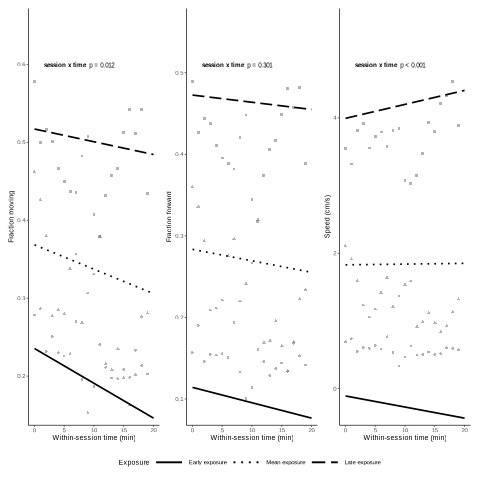

In [32]:
%%R -i hab_epoch_df_20min -i fig_dir_str -o hab_epoch_stats_df -o hab_speed_simple_slopes_t_df

library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)
library(patchwork)
library(emmeans)

# --------------------------------------------------
# Use final first-20-min epoch dataframe
# --------------------------------------------------

hab_epoch_df <- hab_epoch_df_20min

# --------------------------------------------------
# Output folder
# --------------------------------------------------

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_epoch_df$animal <- factor(hab_epoch_df$animal)
hab_epoch_df$animal_day <- factor(hab_epoch_df$animal_day)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_epoch_df)]

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Style maps
# --------------------------------------------------

shape_vals <- c(
  "Early exposure" = 16,   # circle
  "Mean exposure"  = 17,   # triangle
  "Late exposure"  = 15    # square
)

linetype_vals <- c(
  "Early exposure" = "solid",
  "Mean exposure"  = "dotted",
  "Late exposure"  = "longdash"
)

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

format_p <- function(p) {
  if (is.na(p)) {
    return("p = NA")
  } else if (p < 0.001) {
    return("p < 0.001")
  } else {
    return(paste0("p = ", sprintf("%.3f", p)))
  }
}

predict_fixed_ci <- function(model, newdata) {
  fixed_formula <- formula(model, fixed.only = TRUE)
  X <- model.matrix(delete.response(terms(fixed_formula)), newdata)
  beta <- fixef(model)
  V <- vcov(model)

  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% V %*% t(X)))

  newdata$fit <- fit
  newdata$se <- se
  newdata$lower <- fit - 1.96 * se
  newdata$upper <- fit + 1.96 * se

  return(newdata)
}

theme_fig <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text = element_text(size = 6),
      legend.title = element_text(size = 7),
      legend.text = element_text(size = 6),
      legend.position = "bottom",
      legend.key.width = unit(0.45, "in"),
      legend.key.height = unit(0.16, "in"),
      plot.title = element_blank(),
      plot.subtitle = element_blank(),
      plot.margin = margin(3, 4, 3, 3)
    )
}

# --------------------------------------------------
# Exposure levels for visualization
# --------------------------------------------------

exposure_min <- min(hab_epoch_df$exposure_session, na.rm = TRUE)
exposure_mean <- mean(hab_epoch_df$exposure_session, na.rm = TRUE)
exposure_max <- max(hab_epoch_df$exposure_session, na.rm = TRUE)

exposure_levels <- data.frame(
  exposure_session = c(exposure_min, exposure_mean, exposure_max),
  exposure_label = c("Early exposure", "Mean exposure", "Late exposure")
)

session_time_seq <- seq(
  min(hab_epoch_df$session_time_min, na.rm = TRUE),
  max(hab_epoch_df$session_time_min, na.rm = TRUE),
  length.out = 100
)

session_time_mean <- mean(hab_epoch_df$session_time_min, na.rm = TRUE)

# --------------------------------------------------
# Fit models and make plots
# --------------------------------------------------

model_list <- list()
stats_list <- list()
plot_list <- list()

for (outcome in primary_outcomes) {

  label_i <- unname(outcome_labels[outcome])

  cat("\n\n==============================\n")
  cat("Fitting:", outcome, "\n")
  cat("==============================\n")

  # -----------------------------
  # Fit LME
  # -----------------------------

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_epoch_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  model_list[[outcome]] <- m

  # -----------------------------
  # Fixed-effect stats
  # -----------------------------

  coef_table <- as.data.frame(summary(m)$coefficients)

  tmp_stats <- data.frame(
    outcome = outcome,
    y_label = label_i,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    row.names = NULL
  )

  stats_list[[outcome]] <- tmp_stats

  # -----------------------------
  # Prediction data
  # -----------------------------

  pred_df <- expand.grid(
    session_time_min = session_time_seq,
    exposure_session = exposure_levels$exposure_session
  ) %>%
    left_join(exposure_levels, by = "exposure_session") %>%
    mutate(
      exposure_session_c = exposure_session - exposure_mean,
      session_time_10m_c = (session_time_min - session_time_mean) / 10
    )

  pred_df <- predict_fixed_ci(m, pred_df)

  pred_df$exposure_label <- factor(
    pred_df$exposure_label,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )

  # -----------------------------
  # Raw binned means for visual reference
  # -----------------------------

  q1 <- quantile(hab_epoch_df$exposure_session, 1/3, na.rm = TRUE)
  q2 <- quantile(hab_epoch_df$exposure_session, 2/3, na.rm = TRUE)

  raw_bin_df <- hab_epoch_df %>%
    mutate(
      session_time_bin = floor(session_time_min),
      exposure_label = case_when(
        exposure_session <= q1 ~ "Early exposure",
        exposure_session >= q2 ~ "Late exposure",
        TRUE ~ "Mean exposure"
      )
    ) %>%
    group_by(exposure_label, session_time_bin) %>%
    summarise(
      y_mean = mean(.data[[outcome]], na.rm = TRUE),
      .groups = "drop"
    )

  raw_bin_df$exposure_label <- factor(
    raw_bin_df$exposure_label,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )

    # -----------------------------
  # Interaction p-value annotation
  # -----------------------------

  int_row <- tmp_stats[tmp_stats$term == "exposure_session_c:session_time_10m_c", ]

  interaction_label <- "session x time"

  p_label <- ifelse(
    int_row$p < 0.001,
    "p < 0.001",
    paste0("p = ", sprintf("%.3f", int_row$p))
  )

  x_range <- range(hab_epoch_df$session_time_min, na.rm = TRUE)
  y_range <- range(c(raw_bin_df$y_mean, pred_df$fit), na.rm = TRUE)

  x_interaction <- x_range[1] + 0.08 * diff(x_range)
  x_pvalue      <- x_range[1] + 0.46 * diff(x_range)

  y_annot <- y_range[2] + 0.05 * diff(y_range)

  # -----------------------------
  # Plot
  # -----------------------------

  p <- ggplot() +

    # Binned raw means
    geom_point(
      data = raw_bin_df,
      aes(
        x = session_time_bin,
        y = y_mean,
        shape = exposure_label
      ),
      alpha = 0.55,
      size = 1.0,
      colour = "grey45",
      show.legend = FALSE
    ) +

    # Model-predicted lines
    geom_line(
      data = pred_df,
      aes(
        x = session_time_min,
        y = fit,
        linetype = exposure_label
      ),
      linewidth = 0.8,
      colour = "black"
    ) +

    # "session x time"
    annotate(
      "text",
      x = x_interaction,
      y = y_annot,
      label = interaction_label,
      hjust = 0,
      vjust = 0.5,
      size = 2.2,
      fontface = "bold"
    ) +

    # p-value
    annotate(
      "text",
      x = x_pvalue,
      y = y_annot,
      label = p_label,
      hjust = 0,
      vjust = 0.5,
      size = 2.2
    ) +

    scale_shape_manual(values = shape_vals, drop = FALSE) +
    scale_linetype_manual(values = linetype_vals, drop = FALSE) +

    scale_y_continuous(
      expand = expansion(mult = c(0.02, 0.16))
    ) +

    labs(
      x = "Within-session time (min)",
      y = label_i,
      linetype = "Exposure"
    ) +

    guides(
      shape = "none",
      linetype = guide_legend(
        title = "Exposure",
        nrow = 1,
        byrow = TRUE,
        override.aes = list(
          linewidth = 0.9,
          alpha = 1,
          colour = "black"
        )
      )
    ) +

    theme_fig()
    
  plot_list[[outcome]] <- p
}

hab_epoch_stats_df <- bind_rows(stats_list)

# --------------------------------------------------
# Simple slopes for speed with Satterthwaite df
# --------------------------------------------------

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(hab_epoch_df) + 1000,
  pbkrtest.limit = nrow(hab_epoch_df) + 1000
)

speed_model <- model_list[["mean_speed_path_cms"]]

exposure_c_values <- c(
  exposure_min - exposure_mean,
  0,
  exposure_max - exposure_mean
)

speed_trends <- emtrends(
  speed_model,
  ~ exposure_session_c,
  var = "session_time_10m_c",
  at = list(exposure_session_c = exposure_c_values),
  lmer.df = "satterthwaite"
)

hab_speed_simple_slopes_t_df <- as.data.frame(
  summary(
    speed_trends,
    infer = c(TRUE, TRUE),
    null = 0
  )
)

hab_speed_simple_slopes_t_df$exposure_label <- c(
  "Early exposure",
  "Mean exposure",
  "Late exposure"
)

print(hab_speed_simple_slopes_t_df)

# --------------------------------------------------
# Combine and save figure
# --------------------------------------------------

p_combined <- plot_list[[primary_outcomes[1]]] +
  plot_list[[primary_outcomes[2]]] +
  plot_list[[primary_outcomes[3]]] +
  plot_layout(nrow = 1, guides = "collect") &
  theme(legend.position = "bottom")

print(p_combined)

ggsave(
  filename = file.path(out_dir, "Fig1_within_session_habituation_3panel.pdf"),
  plot = p_combined,
  width = 7,
  height = 2.1
)

ggsave(
  filename = file.path(out_dir, "Fig1_within_session_habituation_3panel.png"),
  plot = p_combined,
  width = 7,
  height = 2.1,
  dpi = 600
)

# Optional SVG, works if svglite is installed
# ggsave(
#   filename = file.path(out_dir, "Fig1_within_session_habituation_3panel.svg"),
#   plot = p_combined,
#   width = 7,
#   height = 2.1
# )

# --------------------------------------------------
# Save tables
# --------------------------------------------------

write.csv(
  hab_epoch_stats_df,
  file.path(out_dir, "habituation_epoch_session_time_LME_stats_first20min.csv"),
  row.names = FALSE
)

write.csv(
  hab_speed_simple_slopes_t_df,
  file.path(out_dir, "habituation_speed_simple_slopes_early_mean_late_exposure_first20min.csv"),
  row.names = FALSE
)

print(hab_epoch_stats_df)

## 15. Inspect final simple slopes for speed

The speed interaction is followed up using simple slopes of within-session time at early, mean, and late exposure. These slopes use Satterthwaite degrees of freedom so the manuscript can report `t(df)` values.

In [ ]:
display(hab_speed_simple_slopes_t_df)

print(hab_speed_simple_slopes_t_df.columns.tolist())

In [28]:
# Sessions in whole-session dataframe
whole_sessions = (
    hab_session_df[["animal", "date"]]
    .drop_duplicates()
    .assign(in_whole_session=True)
)

# Sessions in 20-min epoch dataframe
epoch_sessions_20min = (
    hab_epoch_df_20min[["animal", "date"]]
    .drop_duplicates()
    .assign(in_epoch_20min=True)
)

session_compare = whole_sessions.merge(
    epoch_sessions_20min,
    on=["animal", "date"],
    how="outer"
)

session_compare["in_whole_session"] = session_compare["in_whole_session"].fillna(False)
session_compare["in_epoch_20min"] = session_compare["in_epoch_20min"].fillna(False)

missing_from_epoch = session_compare[
    (session_compare["in_whole_session"] == True) &
    (session_compare["in_epoch_20min"] == False)
]

display(missing_from_epoch)

,animal,date,in_whole_session,in_epoch_20min
71,NML_08,2026_02_06,True,False
80,NML_08,2026_02_15,True,False


In [29]:
for _, row in missing_from_epoch.iterrows():
    animal = row["animal"]
    date = row["date"]

    print("\nMissing session:", animal, date)

    tmp_all = encoder_epoch_df[
        (encoder_epoch_df["animal"].astype(str) == str(animal)) &
        (encoder_epoch_df["date"].astype(str) == str(date))
    ]

    print("Rows in encoder_epoch_df:", tmp_all.shape[0])

    if tmp_all.shape[0] > 0:
        print("Phase counts:")
        print(tmp_all["phase"].value_counts(dropna=False))

        time_cols = [c for c in tmp_all.columns if "time" in c.lower()]
        print("Time columns:", time_cols)

        if "session_time_min" in tmp_all.columns:
            print(tmp_all["session_time_min"].describe())
        elif "anchor_session_time_min" in tmp_all.columns:
            print(tmp_all["anchor_session_time_min"].describe())

        if "valid_window" in tmp_all.columns:
            print("valid_window counts:")
            print(tmp_all["valid_window"].value_counts(dropna=False))

        if "good_session_basic" in tmp_all.columns:
            print("good_session_basic counts:")
            print(tmp_all["good_session_basic"].value_counts(dropna=False))


Missing session: NML_08 2026_02_06
Rows in encoder_epoch_df: 0

Missing session: NML_08 2026_02_15
Rows in encoder_epoch_df: 492
Phase counts:
phase
habituation    492
Name: count, dtype: int64
Time columns: ['anchor_time_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min']
count    492.000000
mean      32.126302
std        5.925226
min       21.867293
25%       27.013611
50%       32.087608
75%       37.253129
max       42.373018
Name: anchor_session_time_min, dtype: float64
valid_window counts:
valid_window
True    492
Name: count, dtype: int64
good_session_basic counts:
good_session_basic
True    492
Name: count, dtype: int64


In [33]:
# --------------------------------------------------
# QC: whole-session habituation sample size
# --------------------------------------------------

qc_df = hab_session_df.copy()  # or hab_df.copy() if that is your final whole-session dataframe

# One row should correspond to one animal-session
session_cols = ["animal", "date"] if "date" in qc_df.columns else ["animal", "animal_day"]

hab_session_qc = (
    qc_df
    .drop_duplicates(session_cols)
    .groupby("animal")
    .size()
    .reset_index(name="n_habituation_sessions")
    .sort_values("animal")
)

display(hab_session_qc)

n_animals = hab_session_qc["animal"].nunique()
n_sessions = hab_session_qc["n_habituation_sessions"].sum()
min_sessions = hab_session_qc["n_habituation_sessions"].min()
max_sessions = hab_session_qc["n_habituation_sessions"].max()

print(f"Number of animals: {n_animals}")
print(f"Total habituation sessions: {n_sessions}")
print(f"Sessions per animal: {min_sessions}–{max_sessions}")

,animal,n_habituation_sessions
0,NML_04,16
1,NML_05,16
2,NML_06,16
3,NML_07,19
4,NML_08,19


Number of animals: 5
Total habituation sessions: 86
Sessions per animal: 16–19


In [34]:
# --------------------------------------------------
# QC: check whether there are duplicate animal-date rows
# --------------------------------------------------

duplicates = (
    qc_df
    .groupby(session_cols)
    .size()
    .reset_index(name="n_rows")
    .query("n_rows > 1")
)

print("Duplicate animal-session rows:")
display(duplicates)

Duplicate animal-session rows:


,animal,date,n_rows
